# Aggregate Results

Loads the raw per-day evaluation data `eval_raw.py`'s `run_full_evaluation_grid` collects into `8_testing/results/raw_daily/` and provides the readers used to cross-compare forecasters/archetypes. `eval_raw.py` is collection only -- it never reads `raw_daily/` back; all querying/aggregation (including the unfiltered `load_all_pairs`) lives here instead.

`load_all_pairs`/`load_single_price`/`load_dual_price` all rely on the same schema-consistency invariant: every parquet file under `raw_daily/` must share the current column schema. If `evaluate_one_pair`'s columns ever change, `raw_daily/` needs to be wiped and fully regenerated before re-running this notebook.

In [21]:
import pandas as pd
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from eval_raw import RAW_DAILY_DIR

pd.set_option("display.width", 160)

In [8]:
def load_all_pairs() -> pd.DataFrame:
    return pd.read_parquet(RAW_DAILY_DIR)


def load_single_price() -> pd.DataFrame:
    return pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", "single-price")])


def load_dual_price() -> pd.DataFrame:
    return pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", "dual-price")])

## Load

Requires `run_full_evaluation_grid()` to have been run at least once (see `eval_raw.py`) -- `raw_daily/` is empty until then.

In [9]:
df_single = load_single_price()
df_dual = load_dual_price()
print(f"single-price: {len(df_single)} rows, dual-price: {len(df_dual)} rows")
df_single.head()

single-price: 4392 rows, dual-price: 4392 rows


,forecaster_id,price_mode,archetype_name,day,date,total_cost,regret_v_oracle,C_da,C_imb,throughput_MWh,...,crps,bias_MW,p_ch_raw,p_dis_raw,p_ch_r,p_dis_r,soc,p_imb,mean,realised
0,baseline,single-price,balanced,0,2019-07-01 00:00:00+00:00,959.700004,32.836405,990.907096,-31.207092,19.425526,...,0.280942,0.065371,"[0.0, 0.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.71, 0.0, 0.0, 0.0, 0.0, 1.8000000000000003,...","[0.0, 0.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.71, 0.0, 0.0, 0.0, 0.0, 1.8000000000000003,...","[0.20000000000000018, 0.20000000000000018, 2.1...","[-0.016698737566767097, -0.06189280814946452, ...","[1.6266987518718818, 1.5218928462964372, 1.447...","[1.6100000143051147, 1.4600000381469727, 1.419..."
1,baseline,single-price,balanced,1,2019-07-02 00:00:00+00:00,835.592088,71.925924,1022.691693,-187.099605,19.625789,...,0.183748,0.269050,"[0.0, 0.0, 0.0, 2.0, 0.10526315789473695, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.80000000...","[0.0, 0.0, 0.0, 2.0, 0.10526315789473695, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.80000000...","[2.0, 2.0, 2.0, 3.9, 4.0, 4.0, 4.0, 2.10526315...","[-0.03908308296639973, -0.05546308201930983, -...","[1.619083125881744, 1.5054631297030256, 1.4237...","[1.5800000429153442, 1.4500000476837158, 1.379..."
2,baseline,single-price,balanced,2,2019-07-03 00:00:00+00:00,777.201399,-93.759859,764.557600,12.643799,19.625789,...,0.226859,-0.143013,"[2.0, 0.0, 0.10526315789473695, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.800...","[2.0, 0.0, 0.10526315789473695, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.8, ...","[3.9, 3.9, 4.0, 4.0, 4.0, 4.0, 4.0, 1.89473684...","[0.06475010354534838, -0.016414830753082477, 0...","[1.5852498726127935, 1.4764148689000551, 1.391...","[1.649999976158142, 1.4600000381469727, 1.3999..."
3,baseline,single-price,balanced,3,2019-07-04 00:00:00+00:00,681.960513,22.966601,874.331125,-192.370612,16.021053,...,0.157993,0.210801,"[0.0, 0.0, 0.10526315789473695, 2.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8000000000000...","[0.0, 0.0, 0.10526315789473695, 2.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8000000000000...","[2.0, 2.0, 2.1, 4.0, 4.0, 4.0, 2.1052631578947...","[0.017546833078194934, -0.019100664831997127, ...","[1.5924531812269198, 1.4891006934422266, 1.412...","[1.6100000143051147, 1.4700000286102295, 1.409..."
4,baseline,single-price,balanced,4,2019-07-05 00:00:00+00:00,568.833181,-13.588862,961.024998,-392.191817,19.625789,...,0.287408,0.396028,"[0.0, 0.0, 2.0, 0.10526315789473695, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.800...","[0.0, 0.0, 2.0, 0.10526315789473695, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.8, ...","[2.0, 2.0, 3.9, 4.0, 4.0, 4.0, 4.0, 1.89473684...","[-0.03539220289570255, -0.040629834307757795, ...","[1.6153922458110468, 1.4906298819914736, 1.413...","[1.5800000429153442, 1.4500000476837158, 1.379..."


## Shared helpers

`all_df` is the full unfiltered table (`load_all_pairs()`), used by every section below --
Q2/Q3 need archetype-crossing that `df_single`/`df_dual` alone don't make convenient.

`dfl_id(mode, archetype_name)` maps a (price_mode, archetype) pair onto the DFL
forecaster_id trained ON that archetype -- `"balanced"` keeps the unsuffixed
`dfl_1stage_{mode}.pt` name (see `train_dfl_forecasts.py`/`eval_raw.FORECASTERS`), the
other two archetypes get a `_{name}` suffix. Used throughout: Q1 always calls it with
`"balanced"` (the standard-battery DFL checkpoint); Q2/Q3 call it with the archetype being
asked about (Q2: the archetype matching the eval; Q3: swept over every train archetype
against every eval archetype).

**Current caveat**: `raw_daily/` right now only holds the 10-day smoke-test run
(`eval_raw.py --smoke 10`), not the full test year -- every table/figure below will show
smoke-scale numbers until `run_full_evaluation_grid()` is run for real. The code itself
doesn't care how many days are cached, so this whole notebook is being built/tested
against the smoke data now and will just reflect real numbers once the full grid runs.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from train_dfl_forecasts import ARCHETYPES

ARCHETYPE_NAMES = [name for name, *_ in ARCHETYPES]   # ["short_sharp", "balanced", "long_slow"]


def dfl_id(mode: str, archetype_name: str) -> str:
    suffix = "" if archetype_name == "balanced" else f"_{archetype_name}"
    return f"dfl_1stage_{mode}{suffix}"


all_df = load_all_pairs()
print(f"all_df: {len(all_df)} rows | forecaster_ids: {sorted(all_df['forecaster_id'].unique())} | "
      f"archetypes: {sorted(all_df['archetype_name'].unique())} | "
      f"days/pair: {all_df.groupby(['forecaster_id', 'price_mode', 'archetype_name']).size().min()}"
      f"-{all_df.groupby(['forecaster_id', 'price_mode', 'archetype_name']).size().max()}")

all_df: 8784 rows | forecaster_ids: ['baseline', 'dfl_1stage_dual-price', 'dfl_1stage_dual-price_long_slow', 'dfl_1stage_dual-price_short_sharp', 'dfl_1stage_single-price', 'dfl_1stage_single-price_long_slow', 'dfl_1stage_single-price_short_sharp'] | archetypes: ['balanced', 'long_slow', 'short_sharp'] | days/pair: 366-366


## Q1 -- Does DFL reduce cost (with an accuracy trade-off)?

Standard/balanced archetype only, single & dual-price. Compares `baseline` against the
balanced-trained DFL checkpoint (`dfl_id(mode, "balanced")`) -- NOT the archetype
specialists, those are Q2/Q3's territory.

Table columns: mean daily cost, median day-by-day Δ vs baseline, % change (mean-based),
win rate (fraction of days DFL's cost < baseline's), mean CRPS. No significance test for
now (Wilcoxon removed by request -- may be added back later).

**Pairing note**: `evaluate_one_pair` silently `continue`s past any day its solve raises
on, so a forecaster's day set is not guaranteed to match another's 1:1 by row position.
Every paired comparison below joins on `day` rather than stacking positionally, and warns
if the join drops any days.

**CRPS is archetype-invariant** -- it's a pure function of the forecaster's quantile
output and the realised value, so `mean_crps` here is really a property of the
forecaster/mode pair, not something conditional on the balanced battery specifically. It's
reported alongside cost because that's the comparison set Q1 is about, not because CRPS
itself varies with archetype.

In [11]:
def q1_pair(mode: str) -> pd.DataFrame:
    dfl_forecaster = dfl_id(mode, "balanced")
    sub = all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == "balanced")
                 & (all_df["forecaster_id"].isin(["baseline", dfl_forecaster]))]
    base = sub[sub["forecaster_id"] == "baseline"].set_index("day")
    dfl = sub[sub["forecaster_id"] == dfl_forecaster].set_index("day")

    paired = base[["total_cost"]].join(dfl[["total_cost"]], lsuffix="_base", rsuffix="_dfl", how="inner")
    if len(paired) < max(len(base), len(dfl)):
        print(f"  [{mode}] WARNING: {len(base)} baseline days, {len(dfl)} dfl days, "
              f"{len(paired)} after inner join on 'day' -- some day(s) dropped")
    delta = paired["total_cost_dfl"] - paired["total_cost_base"]

    rows = []
    for forecaster_id, frame in [("baseline", base), (dfl_forecaster, dfl)]:
        is_baseline = forecaster_id == "baseline"
        rows.append({
            "market": mode, "forecaster": forecaster_id,
            "mean_daily_cost": frame["total_cost"].mean(),
            "median_delta_vs_baseline": np.nan if is_baseline else delta.median(),
            "pct_change": np.nan if is_baseline else 100 * delta.mean() / paired["total_cost_base"].mean(),
            "win_rate": np.nan if is_baseline else float((delta < 0).mean()),
            "mean_crps": frame["crps"].mean(),
        })
    return pd.DataFrame(rows)


q1_table = pd.concat([q1_pair("single-price"), q1_pair("dual-price")], ignore_index=True)
q1_table

,market,forecaster,mean_daily_cost,median_delta_vs_baseline,pct_change,win_rate,mean_crps
0,single-price,baseline,1747.250426,NaN,NaN,NaN,0.267694
1,single-price,dfl_1stage_single-price,1741.954190,-2.577588,-0.303118,0.576503,0.290603
2,dual-price,baseline,2089.960773,NaN,NaN,NaN,0.267694
3,dual-price,dfl_1stage_dual-price,1969.854509,-110.922698,-5.746819,0.844262,0.267339


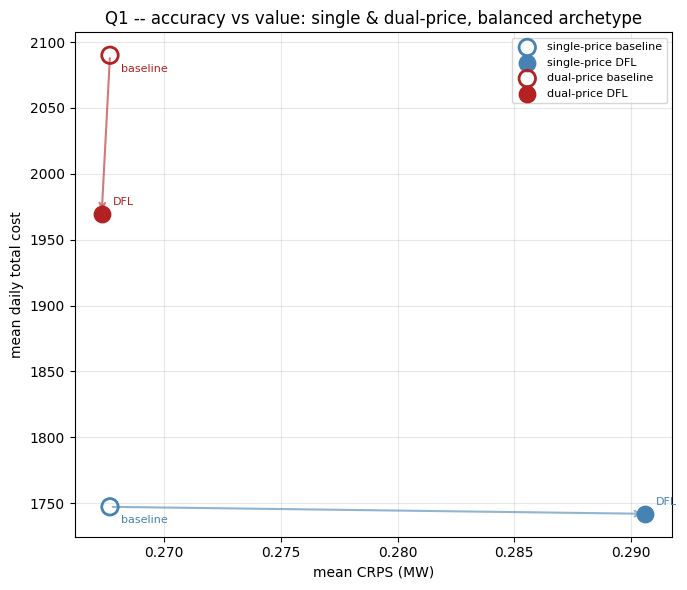

In [19]:
def plot_q1_scatter():
    """Both markets on ONE scatter -- baseline and the balanced-trained DFL for each
    market, same 4 points q1_table summarises (2 per market). Color = market, hollow vs
    filled marker = baseline vs DFL, and an arrow from baseline -> DFL per market shows
    the accuracy/value trade-off direction directly rather than requiring the reader to
    compare two separate figures."""
    colors = {"single-price": "steelblue", "dual-price": "firebrick"}
    fig, ax = plt.subplots(figsize=(7, 6))

    for mode, color in colors.items():
        dfl_forecaster = dfl_id(mode, "balanced")
        sub = all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == "balanced")
                     & (all_df["forecaster_id"].isin(["baseline", dfl_forecaster]))]
        g = sub.groupby("forecaster_id").agg(mean_crps=("crps", "mean"), mean_cost=("total_cost", "mean"))
        base_pt, dfl_pt = g.loc["baseline"], g.loc[dfl_forecaster]

        ax.annotate("", xy=(dfl_pt["mean_crps"], dfl_pt["mean_cost"]),
                    xytext=(base_pt["mean_crps"], base_pt["mean_cost"]),
                    arrowprops=dict(arrowstyle="->", color=color, alpha=0.6, lw=1.5))
        ax.scatter(base_pt["mean_crps"], base_pt["mean_cost"], s=140, facecolors="none",
                   edgecolors=color, linewidths=2, zorder=3, label=f"{mode} baseline")
        ax.scatter(dfl_pt["mean_crps"], dfl_pt["mean_cost"], s=140, color=color,
                   zorder=3, label=f"{mode} DFL")
        ax.annotate("baseline", (base_pt["mean_crps"], base_pt["mean_cost"]),
                    textcoords="offset points", xytext=(8, -12), fontsize=8, color=color)
        ax.annotate("DFL", (dfl_pt["mean_crps"], dfl_pt["mean_cost"]),
                    textcoords="offset points", xytext=(8, 6), fontsize=8, color=color)

    ax.set_xlabel("mean CRPS (MW)")
    ax.set_ylabel("mean daily total cost")
    ax.set_title("Q1 -- accuracy vs value: single & dual-price, balanced archetype")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    plt.show()


plot_q1_scatter()

## Q2 -- Does battery character modulate DFL's benefit?

Each archetype's own **specialist** forecaster (`dfl_id(mode, archetype_name)`) evaluated
on its own matching archetype, vs `baseline` on that same archetype -- the matched/
diagonal comparison, deliberately NOT a single generalist model swept across archetypes
(that would conflate battery physics with forecaster mismatch, which is what Q3 is for).

X-axis is the archetype name as a plain category (`short_sharp` / `balanced` /
`long_slow`) -- NOT positioned by duration, so the bar chart doesn't imply any spacing/
scale relationship between archetypes. Separate figure per market; within each figure, the
benefit bar chart sits beside its saturation-split mechanism chart so the "benefit tracks
scarce slack" argument reads directly off the pair. No significance test for now.

Saturation split uses `baseline`'s `sat_hours_soc`/`sat_hours_rate` (never the specialist
DFL's own) -- baseline's saturation is a fixed reference characterising each archetype's
inherent SOC-vs-rate bottleneck, independent of which forecaster is being evaluated. Using
the specialist's own saturation to explain the specialist's own benefit would be close to
circular.

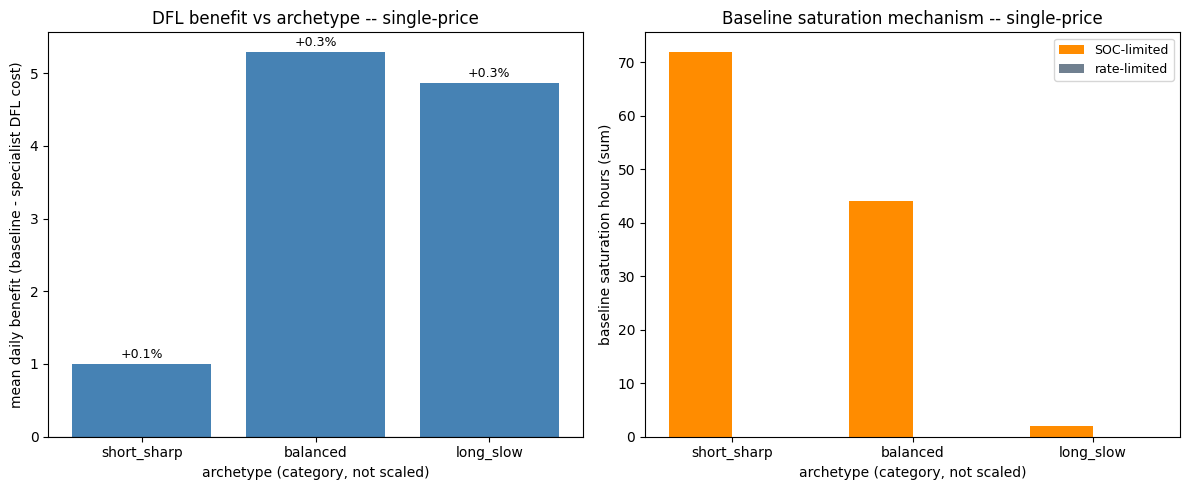

In [13]:
def q2_benefit_by_archetype(mode: str) -> pd.DataFrame:
    """One row per archetype: specialist (matched) forecaster vs baseline, both evaluated
    on that archetype. Joins on 'day' per archetype, same reasoning as q1_pair."""
    rows = []
    for arch in ARCHETYPE_NAMES:
        specialist = dfl_id(mode, arch)
        sub = all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == arch)
                     & (all_df["forecaster_id"].isin(["baseline", specialist]))]
        base = sub[sub["forecaster_id"] == "baseline"].set_index("day")
        dfl = sub[sub["forecaster_id"] == specialist].set_index("day")
        paired = base[["total_cost"]].join(dfl[["total_cost"]], lsuffix="_base", rsuffix="_dfl", how="inner")
        if len(paired) < max(len(base), len(dfl)):
            print(f"  [{mode}/{arch}] WARNING: {len(base)} baseline days, {len(dfl)} dfl days, "
                  f"{len(paired)} after inner join on 'day' -- some day(s) dropped")
        benefit = paired["total_cost_base"] - paired["total_cost_dfl"]     # positive = DFL cheaper
        rows.append({
            "archetype": arch,
            "mean_benefit": benefit.mean(),
            "pct_benefit": 100 * benefit.mean() / paired["total_cost_base"].mean(),
        })
    return pd.DataFrame(rows).set_index("archetype").loc[ARCHETYPE_NAMES]


def q2_baseline_saturation_by_archetype(mode: str) -> pd.DataFrame:
    sub = all_df[(all_df["price_mode"] == mode) & (all_df["forecaster_id"] == "baseline")]
    return sub.groupby("archetype_name")[["sat_hours_soc", "sat_hours_rate"]].sum().loc[ARCHETYPE_NAMES]


def plot_q2(mode: str):
    benefit = q2_benefit_by_archetype(mode)
    sat = q2_baseline_saturation_by_archetype(mode)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    bars = ax1.bar(benefit.index, benefit["mean_benefit"], color="steelblue")
    for bar, pct in zip(bars, benefit["pct_benefit"]):
        ax1.annotate(f"{pct:+.1f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.set_ylabel("mean daily benefit (baseline - specialist DFL cost)")
    ax1.set_xlabel("archetype (category, not scaled)")
    ax1.set_title(f"DFL benefit vs archetype -- {mode}")

    x = np.arange(len(sat.index))
    width = 0.35
    ax2.bar(x - width / 2, sat["sat_hours_soc"], width, label="SOC-limited", color="darkorange")
    ax2.bar(x + width / 2, sat["sat_hours_rate"], width, label="rate-limited", color="slategray")
    ax2.set_xticks(x); ax2.set_xticklabels(sat.index)
    ax2.set_ylabel("baseline saturation hours (sum)")
    ax2.set_xlabel("archetype (category, not scaled)")
    ax2.set_title(f"Baseline saturation mechanism -- {mode}")
    ax2.legend(fontsize=9)

    fig.tight_layout()
    plt.show()


plot_q2("single-price")

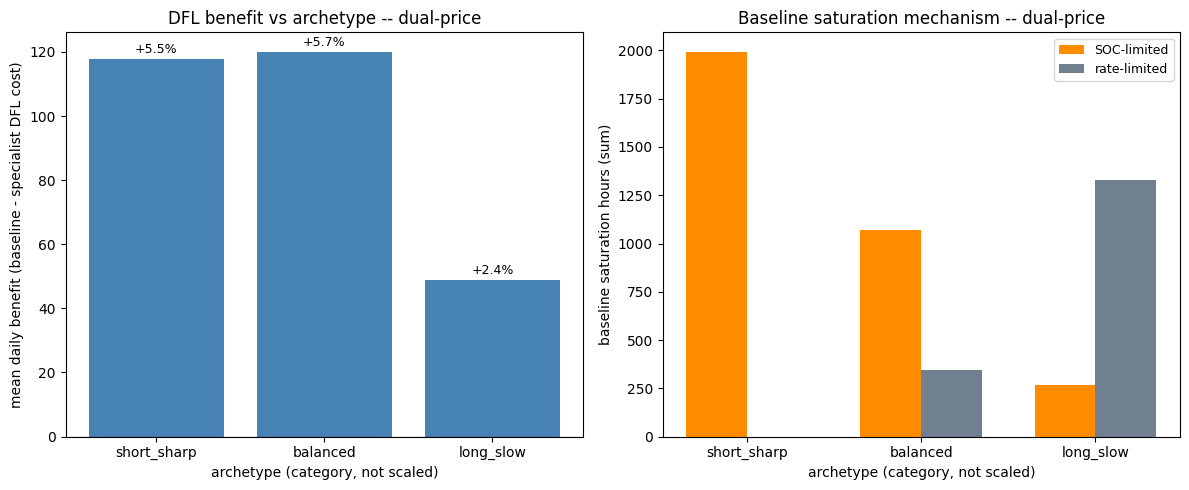

In [14]:
plot_q2("dual-price")

## Q3 -- Do gains transfer across battery setups (specialist vs general)?

Transfer matrix: rows = train archetype (which archetype the DFL checkpoint was trained
on), columns = eval archetype (which archetype it's evaluated against) -- the full 3x3
crossing `eval_raw.py`'s design deliberately leaves unrestricted. Cell value is **benefit
over baseline** (`baseline`'s mean cost on the eval archetype minus that
train-archetype-specialist's mean cost on the same eval archetype), not raw cost -- this
cancels each archetype's own cost-scale (`long_slow`'s bigger capacity changes the cost
level regardless of forecaster) so the diagonal-vs-flat read is about specialization only.
One heatmap per market. No significance test for now.

Diagonal-dominant (best on its own row's archetype) -> battery-specific learning.
Flat/column-uniform (same benefit regardless of train archetype) -> battery-general /
deployment-insensitive.

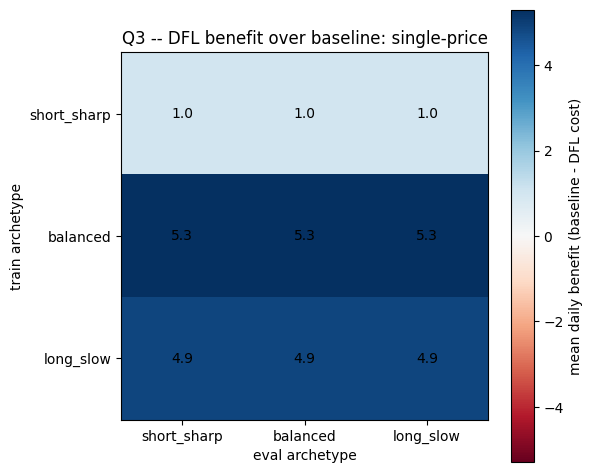

eval_archetype,short_sharp,balanced,long_slow
train_archetype,,,
short_sharp,1.004641,1.004641,1.004641
balanced,5.296236,5.296236,5.296236
long_slow,4.867649,4.867649,4.867649


In [23]:
def q3_matrix(mode: str) -> pd.DataFrame:
    """mat.loc[train_arch, eval_arch] = mean(baseline cost on eval_arch)
    - mean(dfl_id(mode, train_arch) cost on eval_arch), paired on 'day' per cell."""
    mat = pd.DataFrame(index=ARCHETYPE_NAMES, columns=ARCHETYPE_NAMES, dtype=float)
    mat.index.name, mat.columns.name = "train_archetype", "eval_archetype"
    for eval_arch in ARCHETYPE_NAMES:
        base = (all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == eval_arch)
                       & (all_df["forecaster_id"] == "baseline")]
                .set_index("day")[["total_cost"]])
        for train_arch in ARCHETYPE_NAMES:
            specialist = dfl_id(mode, train_arch)
            dfl = (all_df[(all_df["price_mode"] == mode) & (all_df["archetype_name"] == eval_arch)
                          & (all_df["forecaster_id"] == specialist)]
                   .set_index("day")[["total_cost"]])
            paired = base.join(dfl, lsuffix="_base", rsuffix="_dfl", how="inner")
            if len(paired) < max(len(base), len(dfl)):
                print(f"  [{mode}] train={train_arch} eval={eval_arch}: "
                      f"{len(base)} baseline / {len(dfl)} dfl days, {len(paired)} after join -- some dropped")
            mat.loc[train_arch, eval_arch] = (paired["total_cost_base"] - paired["total_cost_dfl"]).mean()
    return mat


def plot_q3_heatmap(mode: str) -> pd.DataFrame:
    mat = q3_matrix(mode)
    vmax = float(mat.abs().to_numpy().max()) or 1.0

    fig, ax = plt.subplots(figsize=(6, 5.2))
    im = ax.imshow(mat.to_numpy(dtype=float), cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(ARCHETYPE_NAMES))); ax.set_xticklabels(ARCHETYPE_NAMES)
    ax.set_yticks(range(len(ARCHETYPE_NAMES))); ax.set_yticklabels(ARCHETYPE_NAMES)
    ax.set_xlabel("eval archetype"); ax.set_ylabel("train archetype")
    ax.set_title(f"Q3 -- DFL benefit over baseline: {mode}")
    for i in range(len(ARCHETYPE_NAMES)):
        for j in range(len(ARCHETYPE_NAMES)):
            ax.text(j, i, f"{mat.iloc[i, j]:.1f}", ha="center", va="center", fontsize=10)
    fig.colorbar(im, ax=ax, label="mean daily benefit (baseline - DFL cost)")
    fig.tight_layout()
    plt.show()
    return mat


plot_q3_heatmap("single-price")

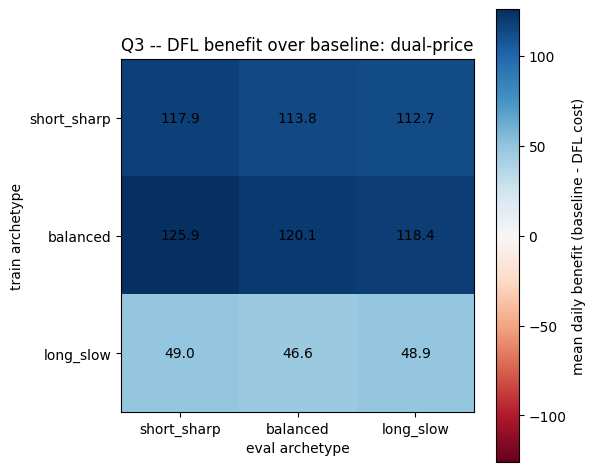

eval_archetype,short_sharp,balanced,long_slow
train_archetype,,,
short_sharp,117.893448,113.773370,112.669817
balanced,125.941792,120.106263,118.438478
long_slow,49.010741,46.580211,48.921980


In [16]:
plot_q3_heatmap("dual-price")